# M1 — Data Understanding, EDA & Stratified Split
**DR-Triage · Diabetic Retinopathy Stage Detection**

This notebook covers rubric item 1 (*Problem Understanding & Dataset Justification*):

1. Load the APTOS 2019 labels and check integrity.
2. Quantify the severity-stage distribution and class imbalance.
3. Profile image properties — resolution, aspect ratio, brightness, sharpness.
4. Show representative fundus images for each of the 5 stages.
5. Produce **one stratified** train / val / test split and prove it preserves class ratios.
6. Record dataset justification, limitations, ethics, and the data-leakage guard.

Every figure is saved to `outputs/figures/` for the report.

> **Run locally (VS Code):**
> 1. `python -m venv .venv && source .venv/bin/activate && pip install -r requirements.txt`
> 2. `python scripts/get_data.py`  (or drop the data into `data/aptos2019/` manually)
> 3. Open this notebook, select the `.venv` kernel, *Run All*.
>
> **Run on Kaggle:**
> 1. *Add Input → Competitions → APTOS 2019 Blindness Detection* (accept the rules first).
> 2. *Add Input → Upload* the `dr-triage.zip` project bundle; name it `dr-triage`.
> 3. *Run All*. The Setup cell locates the code (local folder or uploaded dataset)
>    and points `config.yaml` at whichever APTOS copy it finds.

In [1]:
# --- Setup ---------------------------------------------------------------------
# Locate the project code (src/ + config.yaml). It is either already beside this
# notebook, or inside a Kaggle dataset we uploaded ("dr-triage.zip"). If it is in
# a read-only /kaggle/input/ dataset, copy it to /kaggle/working so outputs/ is
# writable, then chdir there so every relative path in the code resolves.
import sys, os, glob, shutil
from pathlib import Path

PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve())
        break

if PROJECT is None:                                  # look inside attached datasets
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1])     # .../<project folder>
        PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
        print(f"copied project code from {src_root} -> {PROJECT}")

assert PROJECT, ("Could not find src/data.py. Upload dr-triage.zip via "
                 "Add Input -> Upload, then re-run this cell.")
os.chdir(PROJECT)
sys.path.insert(0, PROJECT)
print("project root:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from src.data import (load_config, set_seed, load_labels, make_splits,
                      split_summary, class_weights)

sns.set_theme(style="whitegrid", context="talk")
cfg = load_config()
set_seed(cfg["seed"])
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
print("random seed:", cfg["seed"])
cfg["classes"]

project root: /Users/ilmeedesilva/Computer Vision/dr-triage
random seed: 42


{0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative DR'}

## 1. Load labels & integrity checks

In [2]:
df = load_labels(cfg)
print("rows        :", len(df))
print("columns     :", list(df.columns))
print("duplicate ids:", int(df["id_code"].duplicated().sum()))
print("missing stage:", int(df["stage"].isna().sum()))
df.head()

[load_labels] data root: data/aptos2019
rows        : 3662
columns     : ['id_code', 'stage', 'stage_name', 'referable', 'ordinal', 'path']
duplicate ids: 0
missing stage: 0


,id_code,stage,stage_name,referable,ordinal,path
0,000c1434d8d7,2,Moderate,1,"[1, 1, 0, 0]",data/aptos2019/colored_images/Moderate/000c143...
1,001639a390f0,4,Proliferative DR,1,"[1, 1, 1, 1]",data/aptos2019/colored_images/Proliferate_DR/0...
2,0024cdab0c1e,1,Mild,0,"[1, 0, 0, 0]",data/aptos2019/colored_images/Mild/0024cdab0c1...
3,002c21358ce6,0,No DR,0,"[0, 0, 0, 0]",data/aptos2019/colored_images/No_DR/002c21358c...
4,005b95c28852,0,No DR,0,"[0, 0, 0, 0]",data/aptos2019/colored_images/No_DR/005b95c288...


In [3]:
# Confirm every referenced image file exists on disk.
exists = df["path"].map(lambda p: Path(p).exists())
print(f"image files found: {int(exists.sum())} / {len(df)}")
if not exists.all():
    display(df.loc[~exists, ["id_code", "path"]].head())

image files found: 3662 / 3662


## 2. Class (severity-stage) distribution

The label is the **International Clinical DR Severity Scale**: 0 No DR, 1 Mild,
2 Moderate, 3 Severe, 4 Proliferative DR. These are *ordered* — a fact the M4 model
exploits with an ordinal head.

 stage             name  count  percent
     0            No DR   1805     49.3
     1             Mild    370     10.1
     2         Moderate    999     27.3
     3           Severe    193      5.3
     4 Proliferative DR    295      8.1

Imbalance ratio (largest : smallest class) = 9.4 : 1


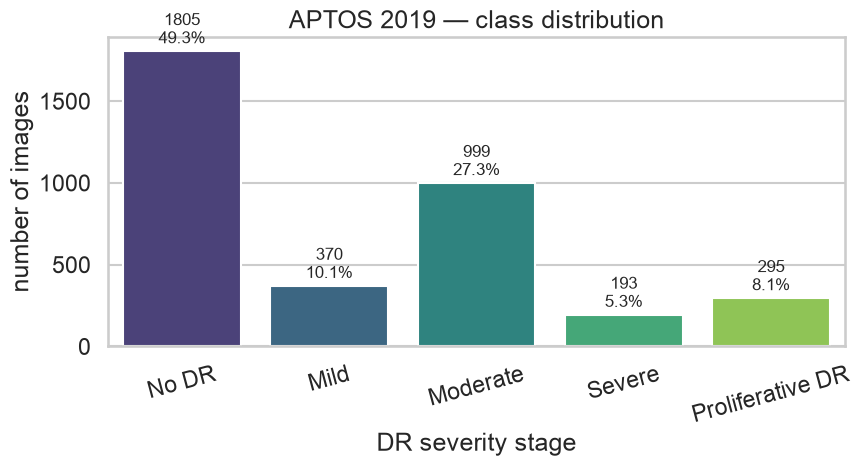

In [4]:
counts = df["stage"].value_counts().sort_index()
dist = pd.DataFrame({
    "stage":   counts.index,
    "name":    [cfg["classes"][s] for s in counts.index],
    "count":   counts.values,
    "percent": (counts.values / len(df) * 100).round(1),
})
imbalance_ratio = counts.max() / counts.min()
print(dist.to_string(index=False))
print(f"\nImbalance ratio (largest : smallest class) = {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=dist, x="name", y="count", hue="name", palette="viridis",
            legend=False, ax=ax)
for i, (c, p) in enumerate(zip(dist["count"], dist["percent"])):
    ax.text(i, c + 20, f"{c}\n{p}%", ha="center", va="bottom", fontsize=12)
ax.set(xlabel="DR severity stage", ylabel="number of images",
       title="APTOS 2019 — class distribution")
plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(FIG / "01_class_distribution.png", dpi=150); plt.show()

## 3. Image property profiling

Sampling up to 400 images to characterise resolution, aspect ratio, brightness, and
sharpness. Sharpness = variance of the Laplacian — the **same signal the M7 quality
gate uses** to reject ungradable photos, so we establish its normal range here.

           w      h  aspect  brightness  sharpness
count  400.0  400.0   400.0      400.00     400.00
mean   224.0  224.0     1.0       67.84     279.43
std      0.0    0.0     0.0       17.31     133.32
min    224.0  224.0     1.0       19.19      29.88
25%    224.0  224.0     1.0       54.04     186.53
50%    224.0  224.0     1.0       69.95     283.04
75%    224.0  224.0     1.0       81.78     358.99
max    224.0  224.0     1.0      120.13    1007.51


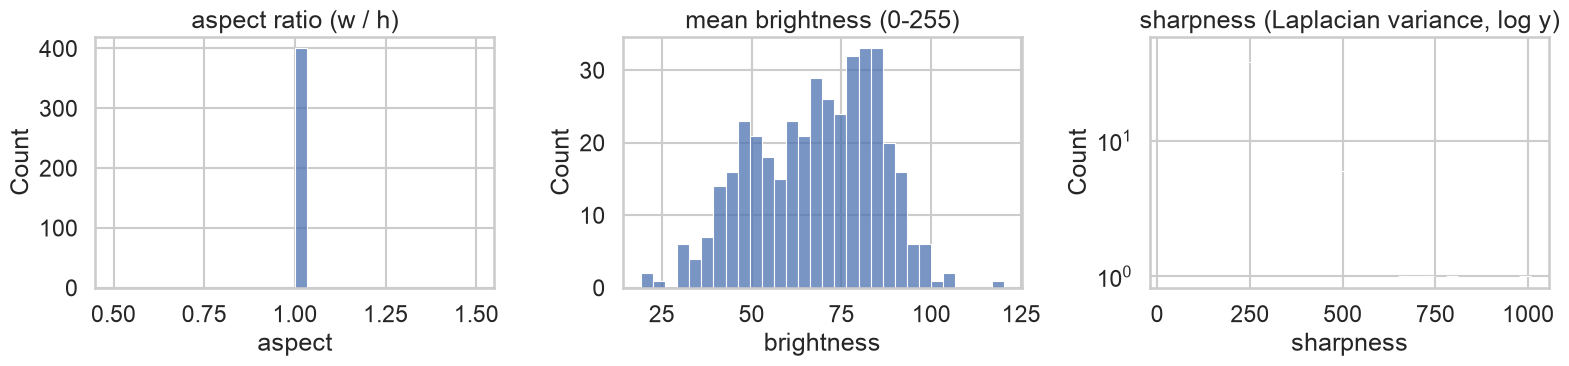

In [5]:
sample = df.sample(min(400, len(df)), random_state=cfg["seed"])
rec = []
for p, s in zip(sample["path"], sample["stage"]):
    im = cv2.imread(p, cv2.IMREAD_COLOR)
    if im is None:
        continue
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    h, w = im.shape[:2]
    rec.append({"stage": int(s), "w": w, "h": h, "aspect": w / h,
                "brightness": float(g.mean()),
                "sharpness": float(cv2.Laplacian(g, cv2.CV_64F).var())})
prof = pd.DataFrame(rec)
print(prof[["w", "h", "aspect", "brightness", "sharpness"]].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(prof["aspect"], bins=30, ax=axes[0]);      axes[0].set_title("aspect ratio (w / h)")
sns.histplot(prof["brightness"], bins=30, ax=axes[1]);  axes[1].set_title("mean brightness (0-255)")
sns.histplot(prof["sharpness"], bins=30, ax=axes[2], log_scale=(False, True))
axes[2].set_title("sharpness (Laplacian variance, log y)")
plt.tight_layout(); plt.savefig(FIG / "01_image_properties.png", dpi=150); plt.show()

## 4. Representative fundus images per stage

Use these in the report to explain *what the model actually sees* — microaneurysms
and dot haemorrhages appear at Mild/Moderate, larger haemorrhages and venous
beading at Severe, and neovascularisation / fibrous proliferation at Proliferative.

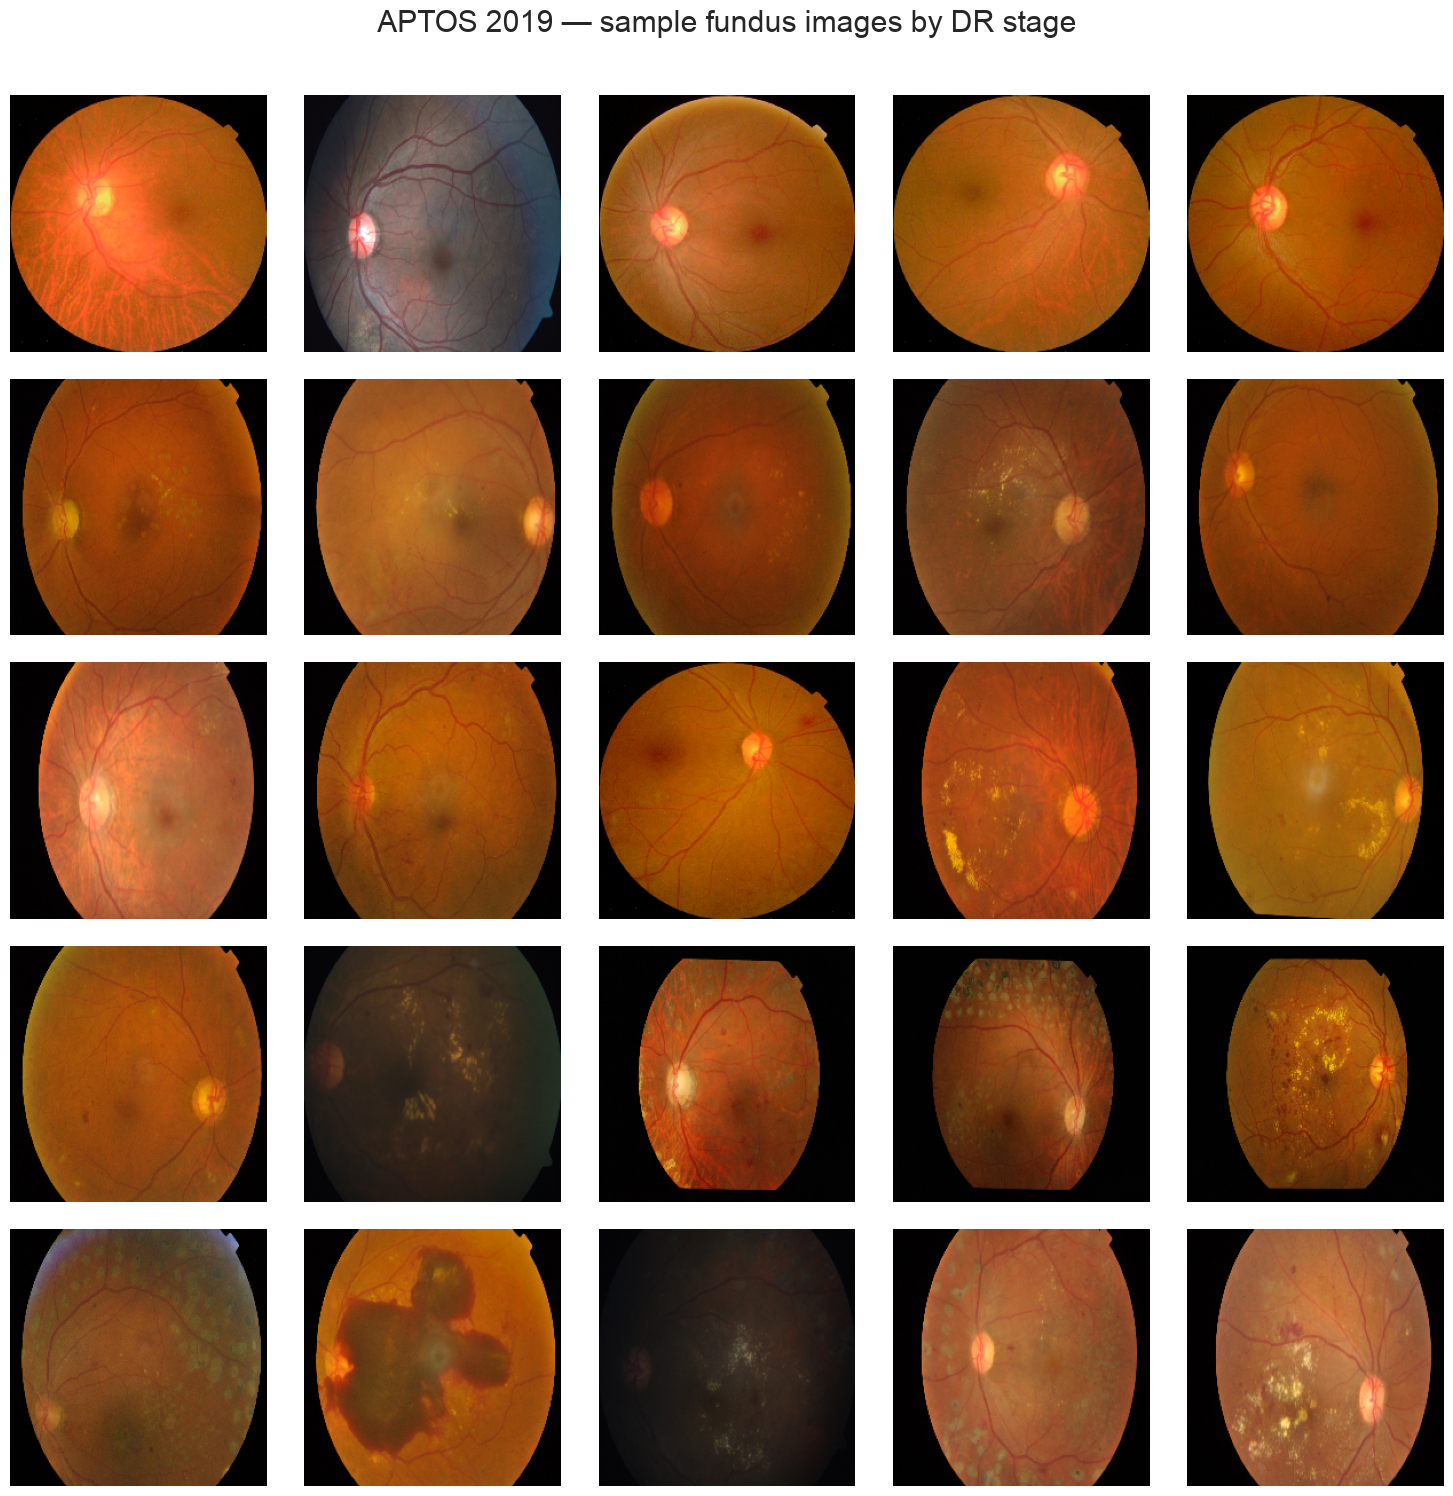

In [6]:
n_per = 5
rows = len(cfg["classes"])
fig, axes = plt.subplots(rows, n_per, figsize=(3 * n_per, 3 * rows))
for r, stage in enumerate(sorted(cfg["classes"])):
    picks = df[df["stage"] == stage].sample(n_per, random_state=cfg["seed"])
    for c, p in enumerate(picks["path"]):
        im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[r, c].imshow(im); axes[r, c].axis("off")
    axes[r, 0].set_ylabel(f"{stage}: {cfg['classes'][stage]}", rotation=0,
                          ha="right", va="center", fontsize=13)
fig.suptitle("APTOS 2019 — sample fundus images by DR stage", y=1.002)
plt.tight_layout()
plt.savefig(FIG / "01_samples_by_stage.png", dpi=150, bbox_inches="tight"); plt.show()

## 5. Stratified train / val / test split

70 / 15 / 15, stratified on the stage label, seeded from `config.yaml`. Written to
`outputs/splits/{train,val,test}.csv` and reloaded by every later notebook so the
splits never drift. **`test.csv` is opened only in notebook 04 (final evaluation).**

[make_splits] wrote train=2562, val=550, test=550 to outputs/splits/
Class share (%) per split — should match column-to-column:

split             train   val  test
stage_name                         
Mild               10.1  10.2  10.2
Moderate           27.3  27.3  27.3
No DR              49.3  49.3  49.3
Proliferative DR    8.1   8.0   8.0
Severe              5.3   5.3   5.3


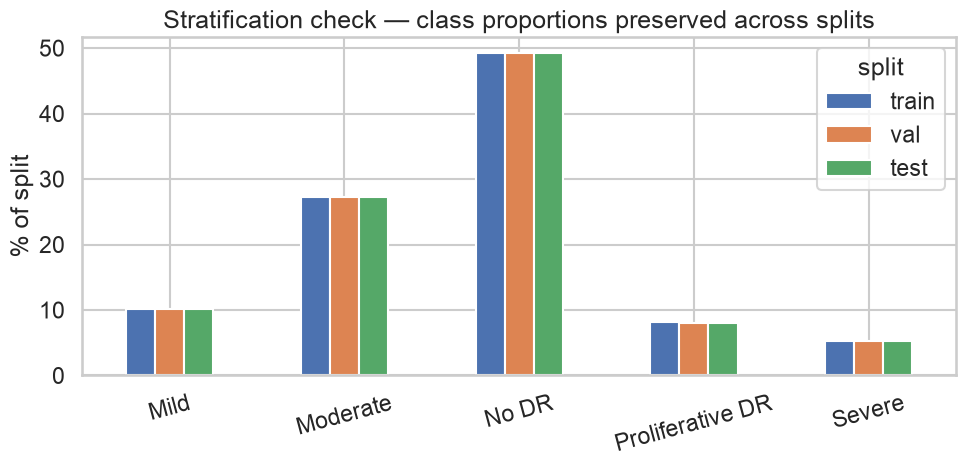

In [7]:
splits = make_splits(df, cfg, save=True)
summary = split_summary(splits, cfg)
pivot = summary.pivot(index="stage_name", columns="split", values="pct")[["train", "val", "test"]]
print("Class share (%) per split — should match column-to-column:\n")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax)
ax.set(ylabel="% of split", xlabel="",
       title="Stratification check — class proportions preserved across splits")
plt.xticks(rotation=15); plt.legend(title="split")
plt.tight_layout(); plt.savefig(FIG / "01_split_proportions.png", dpi=150); plt.show()

In [8]:
w = class_weights(splits["train"], num_classes=len(cfg["classes"]))
print("Inverse-frequency class weights (mean-normalised) for the M4 imbalance-aware loss:\n")
for s, wi in zip(sorted(cfg["classes"]), w):
    print(f"  stage {s} ({cfg['classes'][s]:<16}): {wi:.3f}")
np.save(Path(cfg['paths']['outputs']) / "class_weights.npy", w)

Inverse-frequency class weights (mean-normalised) for the M4 imbalance-aware loss:

  stage 0 (No DR           ): 0.216
  stage 1 (Mild            ): 1.057
  stage 2 (Moderate        ): 0.390
  stage 3 (Severe          ): 2.020
  stage 4 (Proliferative DR): 1.317


## 6. Dataset justification, limitations & ethics  *(report-ready)*

**Why APTOS 2019.** It provides native 5-point severity-stage labels assigned by
trained clinicians, so it matches the coursework task exactly (grade the *stage*, not
just presence/absence). At ~3.6k images it is large enough for transfer learning yet
trains in under an hour on a single Kaggle GPU, allowing several architecture
experiments. Its real, uncorrected class imbalance (ratio reported in §2) lets the
augmentation and balancing work in M3 be *demonstrated and measured* rather than
merely described.

**Known limitations.**
- *Label noise / inter-grader variability* — a single grade per image; borderline
  Mild vs Moderate cases are genuinely ambiguous. This caps achievable accuracy and
  is why M6 reports **quadratic weighted kappa** (agreement) alongside accuracy.
- *Single population, mixed cameras* — images come from clinics in India; brightness
  and field-of-view vary (see §3). A model trained here may not transfer to other
  populations or devices without recalibration.
- *Class imbalance* — Severe and Proliferative are heavily under-represented;
  addressed in M3 (class weights, targeted oversampling, weighted sampler) and
  evaluated per-class in M6.
- *Image-quality variance* — the brightness/sharpness spread in §3 shows some
  near-ungradable images; this motivates the M7 quality gate.

**Ethics.**
- Images are already de-identified; no patient metadata is used or stored.
- The system is a **screening aid, not a diagnostic device** — every output is
  framed as "refer / monitor" and paired with a confidence and an explanation.
- *Automation-bias* risk (clinician over-trusting the model) is mitigated by the
  Grad-CAM overlay, the calibrated confidence, and the MC-Dropout uncertainty flag
  that routes low-confidence cases to a human.
- *Fairness* — performance is only validated on one population; the report states
  this explicitly as a deployment pre-condition.

**Data-leakage guard.**
- The split above is created **before** any preprocessing statistics or augmentation.
- Normalisation statistics (M2) and class weights are computed on **train only**.
- `outputs/splits/test.csv` is read only by notebook `04_evaluate.ipynb`.

## Milestone status
- [x] **M1** — EDA + stratified split complete. Figures saved to `outputs/figures/`.
- [ ] M2 — preprocessing pipeline → `notebooks/02_preprocess_augment.ipynb`